# Fusion des données pour la création de data set

Pour fusionner les données dans un premier temps nous allons charger un à un les fichiers que l’on a collecté : etp.csv et meteo.csv .
Puis dans une boucle nous allons pour chaque fichier du dossier nappes faire la fusion avec les données des 2 fichiers mentionnés avant.

## Imports & variables

In [10]:
import pandas as pd
from scipy.spatial import cKDTree
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

# Fichiers sources
fichier_meteo = "../data/extraction/meteo.csv"
fichier_etp = "../data/extraction/etp.csv"
fichier_imperm = "../data/extraction/impermeabilite.csv"
dossier_nappe = "../data/extraction/nappes/"

# Dossier de sortie pour les données finales
output_folder = "../data/fusion"

## Chargement des données météos

In [11]:
# Lecture des données météo
meteo = pd.read_csv(fichier_meteo, sep=";")

# Sélection des colonnes utiles et renommage pour homogénéité
meteo = meteo[["AAAAMM", "RR", "TMM", "ETP","LAT","LON"]]
meteo = meteo.rename(columns={
    "AAAAMM": "time",
    "RR": "PRELIQ_Q",
    "TMM": "T_Q",
    "LAT": "lat",
    "LON": "lon"
})

# Conversion en datetime
meteo["time"] = pd.to_datetime(meteo["time"].astype(str), format="%Y%m")

# Tri par date et réinitialisation de l'index
meteo_month = meteo.sort_values("time").reset_index(drop=True)



# print(meteo_month.head())

### Affichage des données

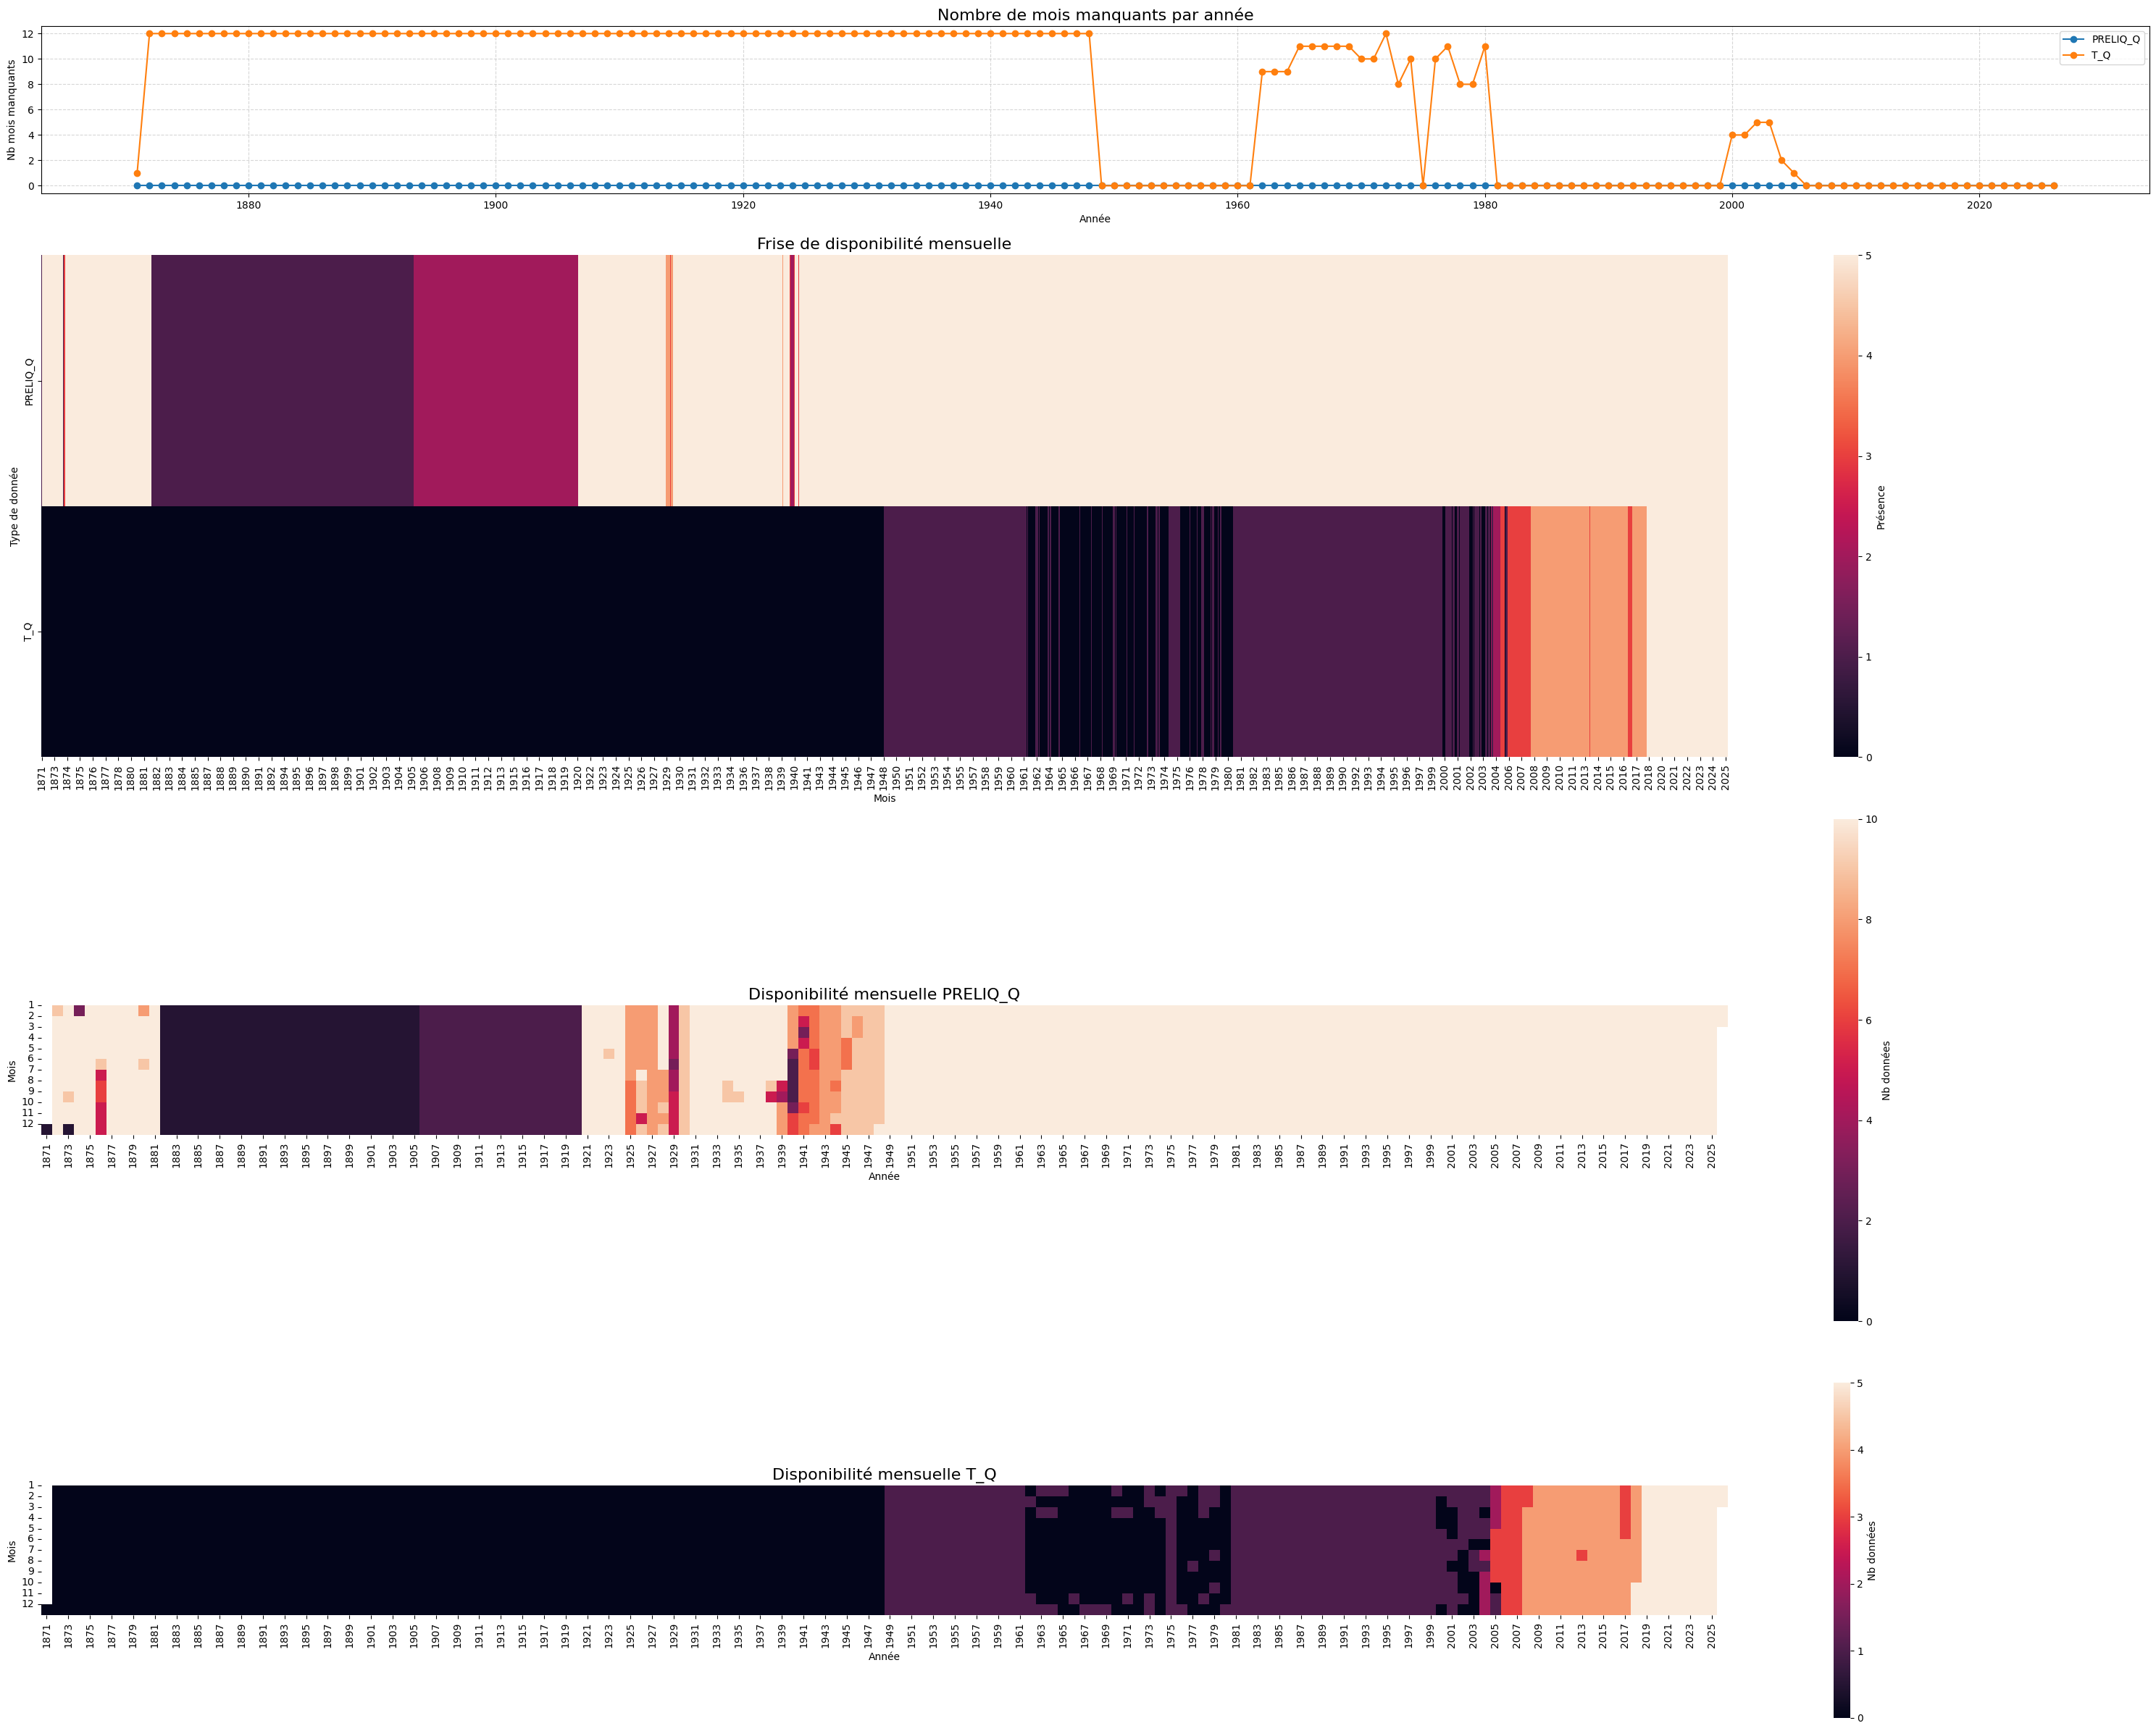

In [12]:
# Création d'une plage temporelle complète du début à la fin des données météo
full_time = pd.date_range(
    start=meteo_month["time"].min(),
    end=meteo_month["time"].max(),
    freq="MS"
)

# Comptage du nombre de données disponibles par mois
chrono = (
    meteo_month
    .groupby("time")[["PRELIQ_Q", "T_Q"]]
    .count()
    .reset_index()
)

# Création d'un DataFrame complet avec tous les mois
chrono_full = pd.DataFrame({"time": full_time})
chrono_full = chrono_full.merge(chrono, on="time", how="left")

# Remplissage des mois manquants par 0
chrono_full[["PRELIQ_Q", "T_Q"]] = chrono_full[["PRELIQ_Q", "T_Q"]].fillna(0)

# Extraction année / mois pour analyses ultérieures
chrono_full["year"] = chrono_full["time"].dt.year
chrono_full["month"] = chrono_full["time"].dt.month

# Comptage des mois manquants par année
missing_year = (
    chrono_full
    .assign(
        PRELIQ_missing = chrono_full["PRELIQ_Q"] == 0,
        T_missing = chrono_full["T_Q"] == 0
    )
    .groupby("year")[["PRELIQ_missing", "T_missing"]]
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(4, 1, figsize=(30, 24), gridspec_kw={'height_ratios':[1,3,3,2]})

missing_year = (
    chrono_full
    .assign(
        PRELIQ_missing = chrono_full["PRELIQ_Q"] == 0,
        T_missing = chrono_full["T_Q"] == 0
    )
    .groupby("year")[["PRELIQ_missing", "T_missing"]]
    .sum()
    .reset_index()
)

axes[0].plot(missing_year["year"], missing_year["PRELIQ_missing"], label="PRELIQ_Q", marker="o")
axes[0].plot(missing_year["year"], missing_year["T_missing"], label="T_Q", marker="o")
axes[0].set_title("Nombre de mois manquants par année", fontsize=16)
axes[0].set_xlabel("Année")
axes[0].set_ylabel("Nb mois manquants")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

frise = chrono_full[["PRELIQ_Q", "T_Q"]].T
frise.columns = chrono_full["time"].dt.to_period("Y").astype(str)
sns.heatmap(
    frise,
    ax=axes[1],
    vmin=0,
    vmax=5,
    yticklabels=["PRELIQ_Q", "T_Q"],
    cbar_kws={"label": "Présence"},
)
axes[1].set_title("Frise de disponibilité mensuelle", fontsize=16)
axes[1].set_xlabel("Mois")
axes[1].set_ylabel("Type de donnée")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90)

heatmap_meteo = chrono_full.pivot(index="month", columns="year", values="PRELIQ_Q")
sns.heatmap(
    heatmap_meteo,
    ax=axes[2],
    vmin=0,
    vmax=10,
    square=True,
    cbar_kws={"label": "Nb données"},
)
axes[2].set_title("Disponibilité mensuelle PRELIQ_Q", fontsize=16)
axes[2].set_xlabel("Année")
axes[2].set_ylabel("Mois")
axes[2].set_yticks(range(0,12))
axes[2].set_yticklabels(range(1,13), rotation=0)

heatmap_temp = chrono_full.pivot(index="month", columns="year", values="T_Q")
sns.heatmap(
    heatmap_temp,
    ax=axes[3],
    vmin=0,
    vmax=5,
    square=True,
    cbar_kws={"label": "Nb données"},
)
axes[3].set_title("Disponibilité mensuelle T_Q", fontsize=16)
axes[3].set_xlabel("Année")
axes[3].set_ylabel("Mois")
axes[3].set_yticks(range(0,12))
axes[3].set_yticklabels(range(1,13), rotation=0)

plt.tight_layout()
plt.show()



## Chargement des données d'évapotranspiration

In [13]:
# Lecture des données ETP
etp = pd.read_csv(fichier_etp, sep=";")

# Conversion de la date en datetime
etp["time"] = pd.to_datetime(etp["DATE"].astype(str), format="%Y%m%d")

# Renommage des colonnes latitude / longitude pour homogénéité
etp = etp.rename(columns={
    "lat_dg": "lat",
    "lon_dg": "lon",
    "ETP_Q_H0175": "ETP_Q"
})

# Passage à la fréquence mensuelle
etp["month"] = etp["time"].dt.to_period("M")

# Agrégation mensuelle par maille (lat/lon)
etp_month = etp.groupby(["lat", "lon", "month"]).agg({
    "ETP_Q": "mean"
}).reset_index()

# Conversion de la période en datetime (début du mois)
etp_month["time"] = etp_month["month"].dt.to_timestamp()

# Suppression de la colonne temporaire
etp_month = etp_month.drop(columns=["month"])



# print(etp_month.head())


### Affichage des données

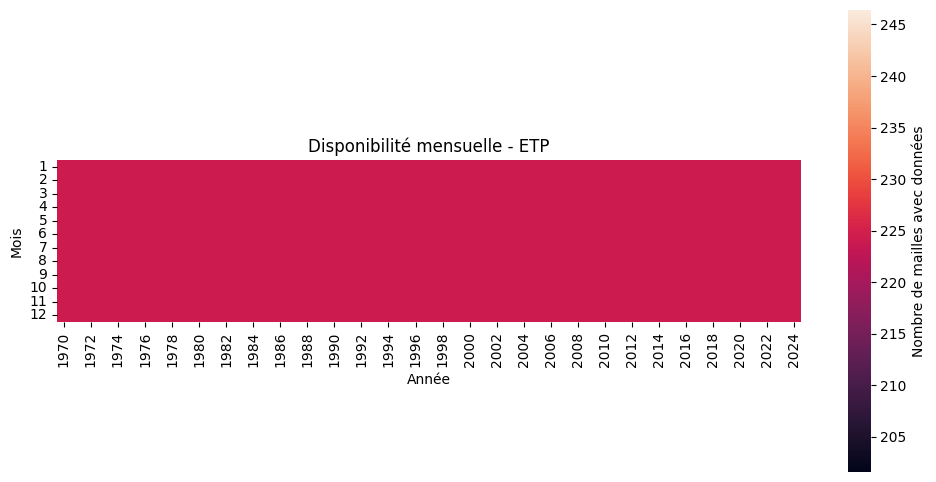

In [14]:
# Comptage du nombre de mailles avec données par mois
chrono_etp = (
    etp_month
    .groupby("time")["ETP_Q"]
    .count()
    .reset_index(name="nb_points")
)

# Création d'une timeline complète pour ne pas perdre les mois manquants
full_time = pd.date_range(
    start=etp_month["time"].min(),
    end=etp_month["time"].max(),
    freq="MS"   # début de mois
)

chrono_full_etp = pd.DataFrame({"time": full_time})

# Fusion avec les données existantes
chrono_full_etp = chrono_full_etp.merge(
    chrono_etp,
    on="time",
    how="left"
)

# Remplissage des mois manquants par 0
chrono_full_etp["nb_points"] = chrono_full_etp["nb_points"].fillna(0)

# Extraction de l'année et du mois
chrono_full_etp["year"] = chrono_full_etp["time"].dt.year
chrono_full_etp["month"] = chrono_full_etp["time"].dt.month

# Pivot pour heatmap 
heatmap_etp = chrono_full_etp.pivot(
    columns="year",
    index="month",
    values="nb_points"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_etp,
    square=True,
    cbar_kws={"label": "Nombre de mailles avec données"}
)

plt.title("Disponibilité mensuelle - ETP")
plt.xlabel("Année")
plt.ylabel("Mois")
plt.show()


## Chargement des données d'imperméabilité

In [15]:
# Lecture des données
imperm = pd.read_csv(fichier_imperm, sep=";")

# Conversion de la date en datetime
imperm["time"] = pd.to_datetime(imperm["time"].astype(int).astype(str) + "-01-01")



# print(imperm.head())

## Fusion

In [21]:
# Créer le dossier de sortie si nécessaire
os.makedirs(output_folder, exist_ok=True)

def nearest_point_valid(df_points, df_target, value_column):
    """
    Trouve pour chaque point cible le point le plus proche
    parmi ceux qui ont une valeur valide dans value_column.
    """
    # Garder seulement les points avec données
    df_valid = df_points.dropna(subset=[value_column])
    
    # S'il n'y a aucune donnée disponible
    if len(df_valid) == 0:
        return None, None
    
    tree = cKDTree(df_valid[["lat", "lon"]].values)
    _, idx = tree.query(df_target[["lat", "lon"]].values)
    
    return df_valid, idx


# Boucle sur tous les fichiers CSV de nappes
for fichier in os.listdir(dossier_nappe):
    if not fichier.endswith(".csv"):
        continue
    
    print("Traitement :", fichier)
    nappe = pd.read_csv(os.path.join(dossier_nappe, fichier), sep=";")
    
    # Préparer les données de nappe
    nappe = nappe.rename(columns={"date_mesure": "time"})
    nappe["time"] = pd.to_datetime(nappe["time"])
    nappe["month"] = nappe["time"].dt.to_period("M")
    
    # Agrégation mensuelle par station
    nappe_month = nappe.groupby(["code_bss", "month"]).agg({
        "niveau_nappe_eau": "mean",
        "lon": "first",
        "lat": "first"
    }).reset_index()
    
    nappe_month["time"] = nappe_month["month"].dt.to_timestamp()
    nappe_month = nappe_month.drop(columns="month")
    
    # Colonnes pour fusion avec ETP et météo
    nappe_month["ETP_Q"] = np.nan
    nappe_month["PRELIQ_Q"] = np.nan
    nappe_month["T_Q"] = np.nan
    
    # Fusion point par point pour chaque date
    dates = nappe_month["time"].unique()
    for d in dates:
        mask = nappe_month["time"] == d
        df_day = nappe_month[mask]
        
        etp_day = etp_month[etp_month["time"] == d]
        meteo_day = meteo_month[meteo_month["time"] == d]

        if len(meteo_day) == 0:
            print("Pas de météo pour :", d)
        
        # Fusion ETP
        if len(etp_day) > 0:
            df_valid, idx_etp = nearest_point_valid(etp_day, df_day, "ETP_Q")
            if df_valid is not None:
                nappe_month.loc[mask, "ETP_Q"] = df_valid.iloc[idx_etp]["ETP_Q"].values
        
        # Fusion Météo
        if len(meteo_day) > 0:
            df_valid, idx_met = nearest_point_valid(meteo_day, df_day, "PRELIQ_Q")
            if df_valid is not None:
                nappe_month.loc[mask, "PRELIQ_Q"] = df_valid.iloc[idx_met]["PRELIQ_Q"].values
            df_valid, idx_met = nearest_point_valid(meteo_day, df_day, "T_Q")
            if df_valid is not None:
                nappe_month.loc[mask, "T_Q"] = df_valid.iloc[idx_met]["T_Q"].values
        
        current_year = pd.Timestamp(d).year
        
        if current_year < 2023:
            ref_year = 2020
        else:
            ref_year = 2023
        
        # Sélection des données d'imperméabilité pour cette année
        imperm_year = imperm[imperm["time"].dt.year == ref_year]

        if len(imperm_year) > 0:
            # Recherche du point géographique le plus proche
            df_valid, idx_imp = nearest_point_valid(imperm_year, df_day, "surface_imp")
            
            if df_valid is not None:
                # Récupération des valeurs
                s_imp = df_valid.iloc[idx_imp]["surface_imp"].values
                s_tot = df_valid.iloc[idx_imp]["surface"].values
                
                # Assignation
                nappe_month.loc[mask, "surface_imp"] = s_imp
                nappe_month.loc[mask, "surface_totale"] = s_tot
    
    # Déterminer le nom de sortie (code BSS du fichier)
    nom_nappe = nappe_month["code_bss"].iloc[0].replace("/", "_")   # supposé unique par fichier
    output_file = f"data_{nom_nappe}.csv"
    
    # Sauvegarde
    nappe_month.to_csv(os.path.join(output_folder, output_file), sep=";", index=False)


Traitement : nappe_02927X1013_P.csv


Traitement : nappe_02928X1008_P.csv
Traitement : nappe_02928X1014_P.csv
Traitement : nappe_02935X1019_P.csv
Traitement : nappe_02936X1018_P.csv
Traitement : nappe_02936X2005_PFAEP.csv
Traitement : nappe_03273X0022_S1.csv
Traitement : nappe_03273X0026_P.csv
Traitement : nappe_03273X0032_S1.csv
Traitement : nappe_03276X0009_P.csv
Traitement : nappe_03276X0057_P.csv
Traitement : nappe_03277X0019_S1.csv
Traitement : nappe_03277X0059_S1.csv
Traitement : nappe_03278X0020_P.csv
Traitement : nappe_03281X0015_P.csv
Traitement : nappe_03281X0019_P.csv
Traitement : nappe_03282X0029_P.csv
Traitement : nappe_03282X0043_S1.csv
Traitement : nappe_03283X0018_P.csv
Traitement : nappe_03283X0020_P.csv
Traitement : nappe_03283X0057_F.csv
Traitement : nappe_03283X0060_F.csv
Traitement : nappe_03284X0012_P1.csv
Traitement : nappe_03284X0014_S1.csv
Traitement : nappe_03285X0032_P.csv
Traitement : nappe_03286X0031_P.csv
Traitement : nappe_03287X0018_S1.csv
Traitement : nappe_03288X0039_S1.csv
Traitement : na

### Affichage des données

Shape : (118, 11)


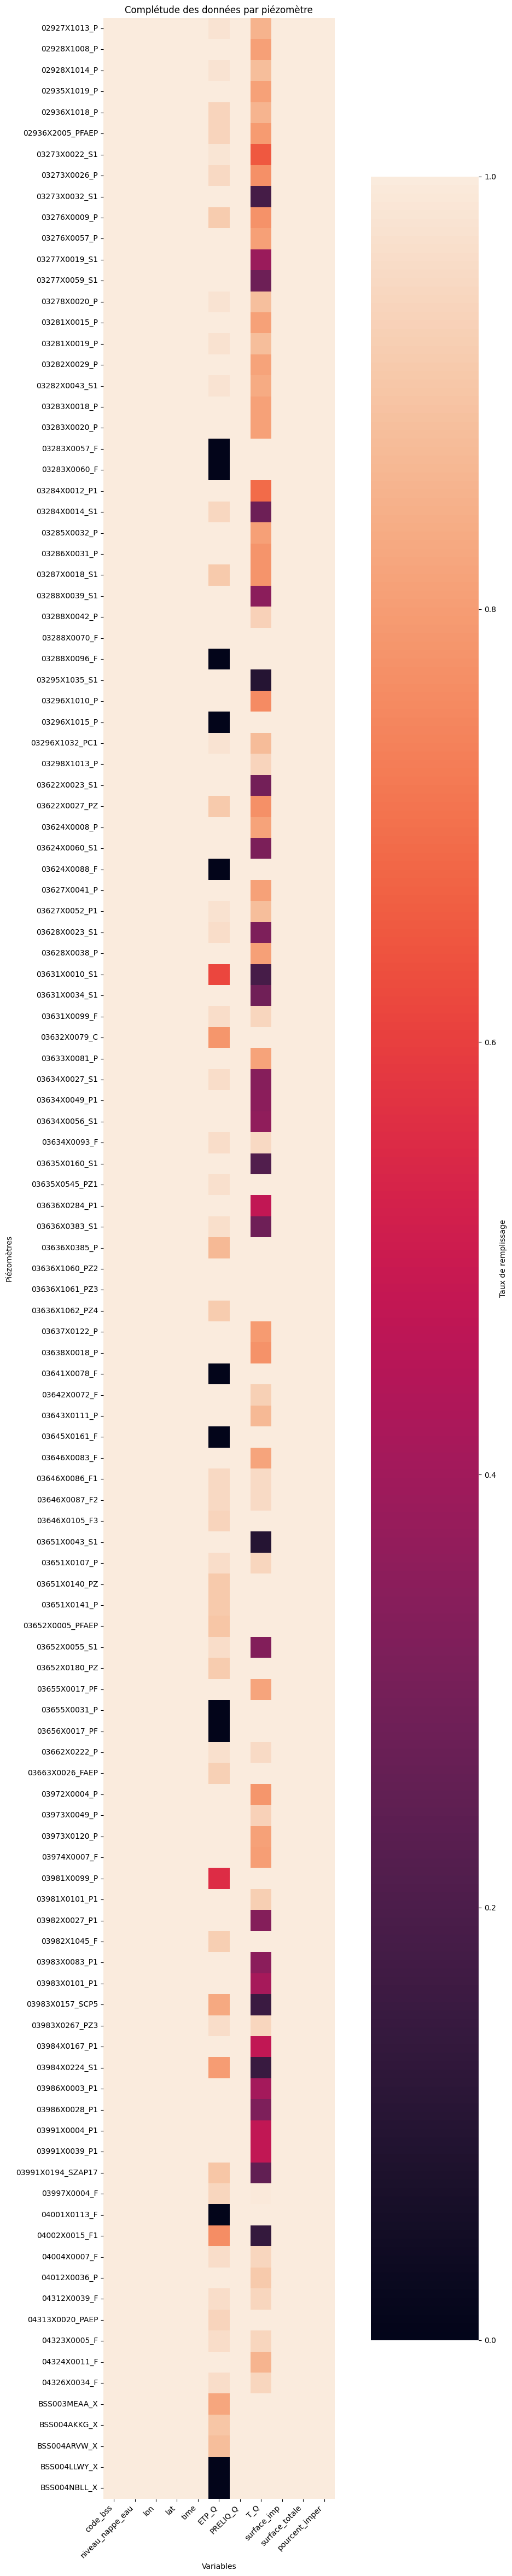

In [17]:
results = []

for file in os.listdir(output_folder):
    if not file.endswith(".csv"):
        continue
    
    path = os.path.join(output_folder, file)
    df = pd.read_csv(path, sep=";")
    
    if len(df) == 0:
        continue
    
    total_rows = len(df)
    
    # Taux de remplissage par colonne
    fill_ratio = df.notna().sum() / total_rows
    
    fill_ratio["file"] = file.replace("data_", "").replace(".csv", "")
    results.append(fill_ratio)

# Construire la matrice
heat_df = pd.DataFrame(results)
heat_df = heat_df.set_index("file")
heat_df = heat_df.sort_index()

print("Shape :", heat_df.shape)

plt.figure(figsize=(14, max(6, len(heat_df) * 0.4)))

sns.heatmap(
    heat_df,
    vmin=0,
    vmax=1,
    square=True,
    cbar_kws={"label": "Taux de remplissage"}
)

plt.title("Complétude des données par piézomètre")
plt.xlabel("Variables")
plt.ylabel("Piézomètres")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


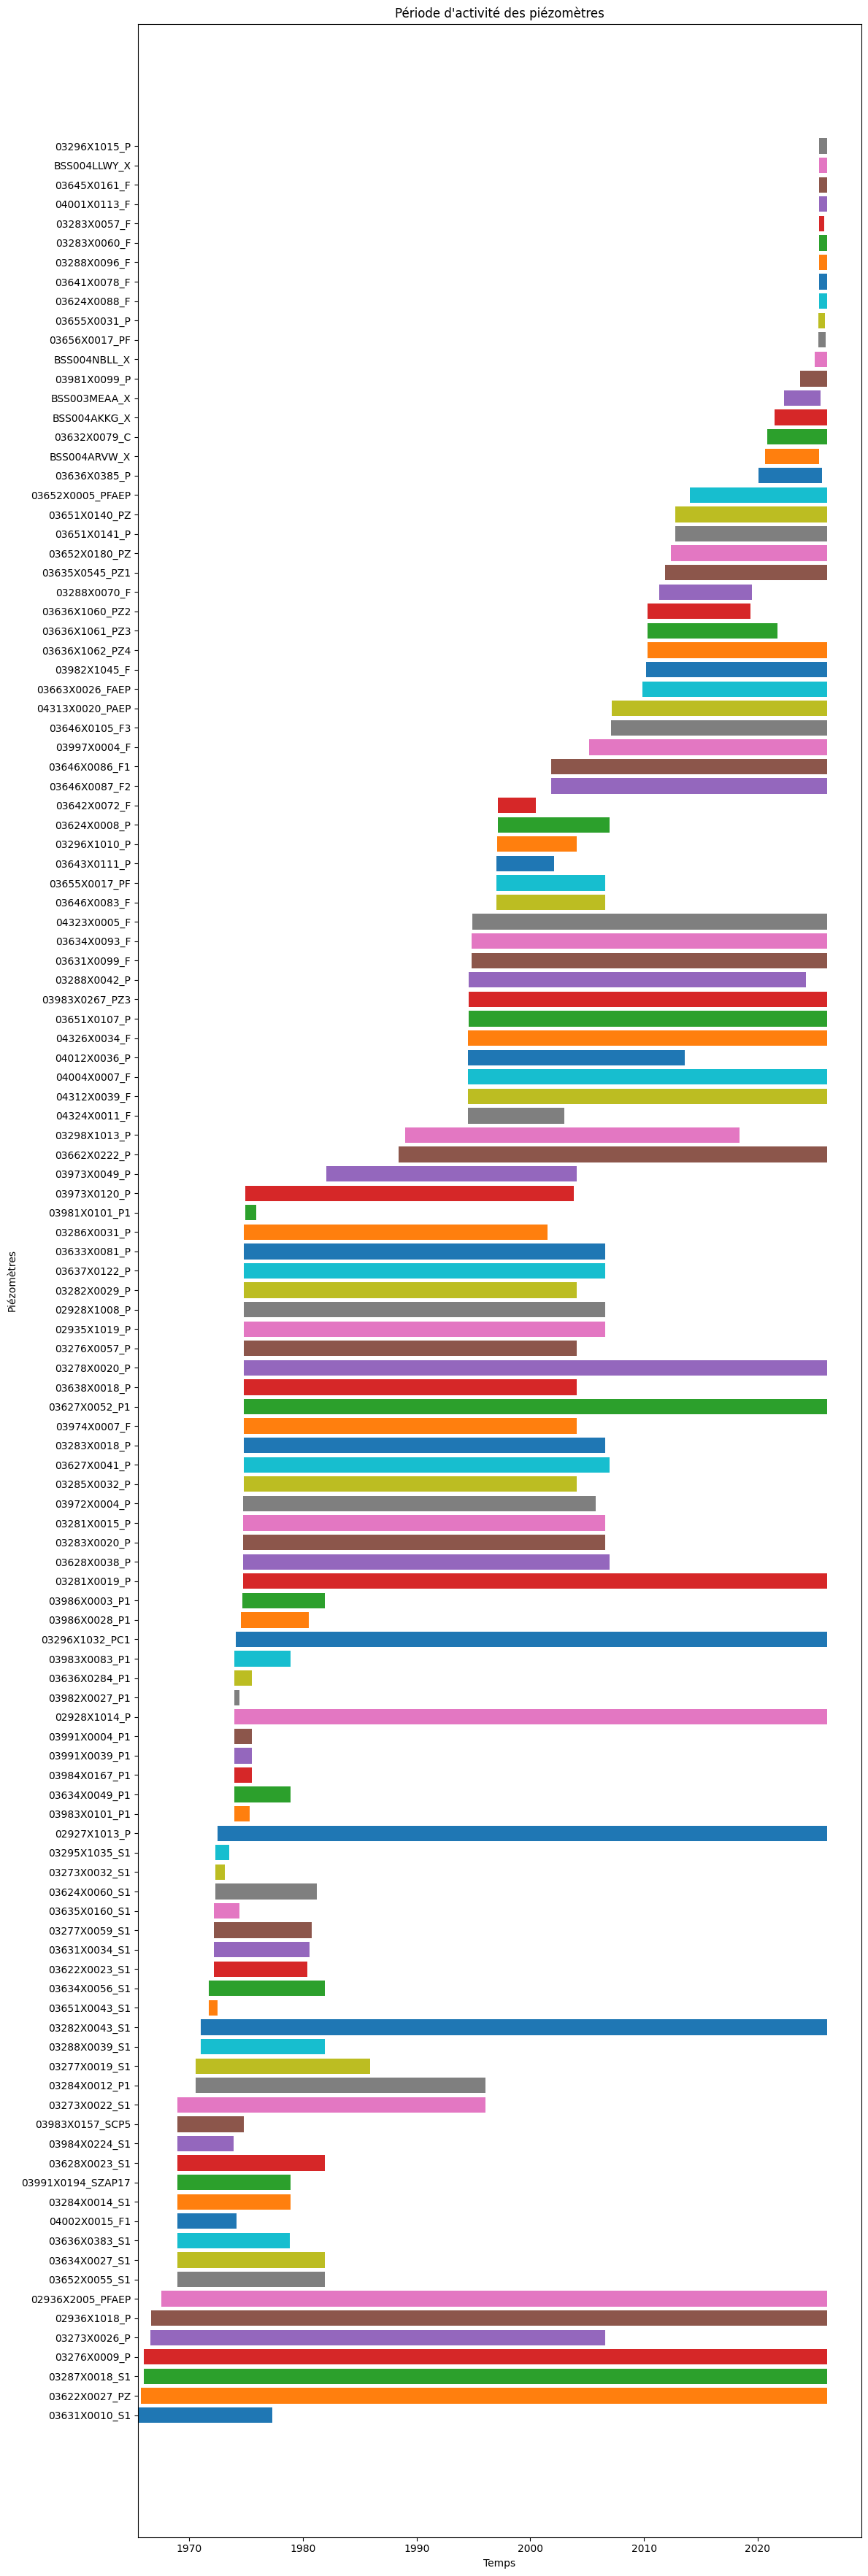

In [18]:
activity = []

for file in os.listdir(output_folder):
    if not file.endswith(".csv"):
        continue
    
    path = os.path.join(output_folder, file)
    df = pd.read_csv(path, sep=";")
    
    if len(df) == 0 or "time" not in df.columns:
        continue
    
    df["time"] = pd.to_datetime(df["time"])
    
    df_valid = df.dropna(how="all")
    
    if len(df_valid) == 0:
        continue
    
    start = df_valid["time"].min()
    end = df_valid["time"].max()
    
    code = file.replace("data_", "").replace(".csv", "")
    
    activity.append({
        "piezometre": code,
        "start": start,
        "end": end
    })

activity_df = pd.DataFrame(activity)
activity_df = activity_df.sort_values("start")

fig, ax = plt.subplots(figsize=(12, max(6, len(activity_df) * 0.3)))

for i, row in activity_df.iterrows():
    ax.barh(
        y=row["piezometre"],
        width=(row["end"] - row["start"]).days,
        left=row["start"]
    )

ax.set_title("Période d'activité des piézomètres")
ax.set_xlabel("Temps")
ax.set_ylabel("Piézomètres")

plt.tight_layout()
plt.show()

Shape : (118, 728)


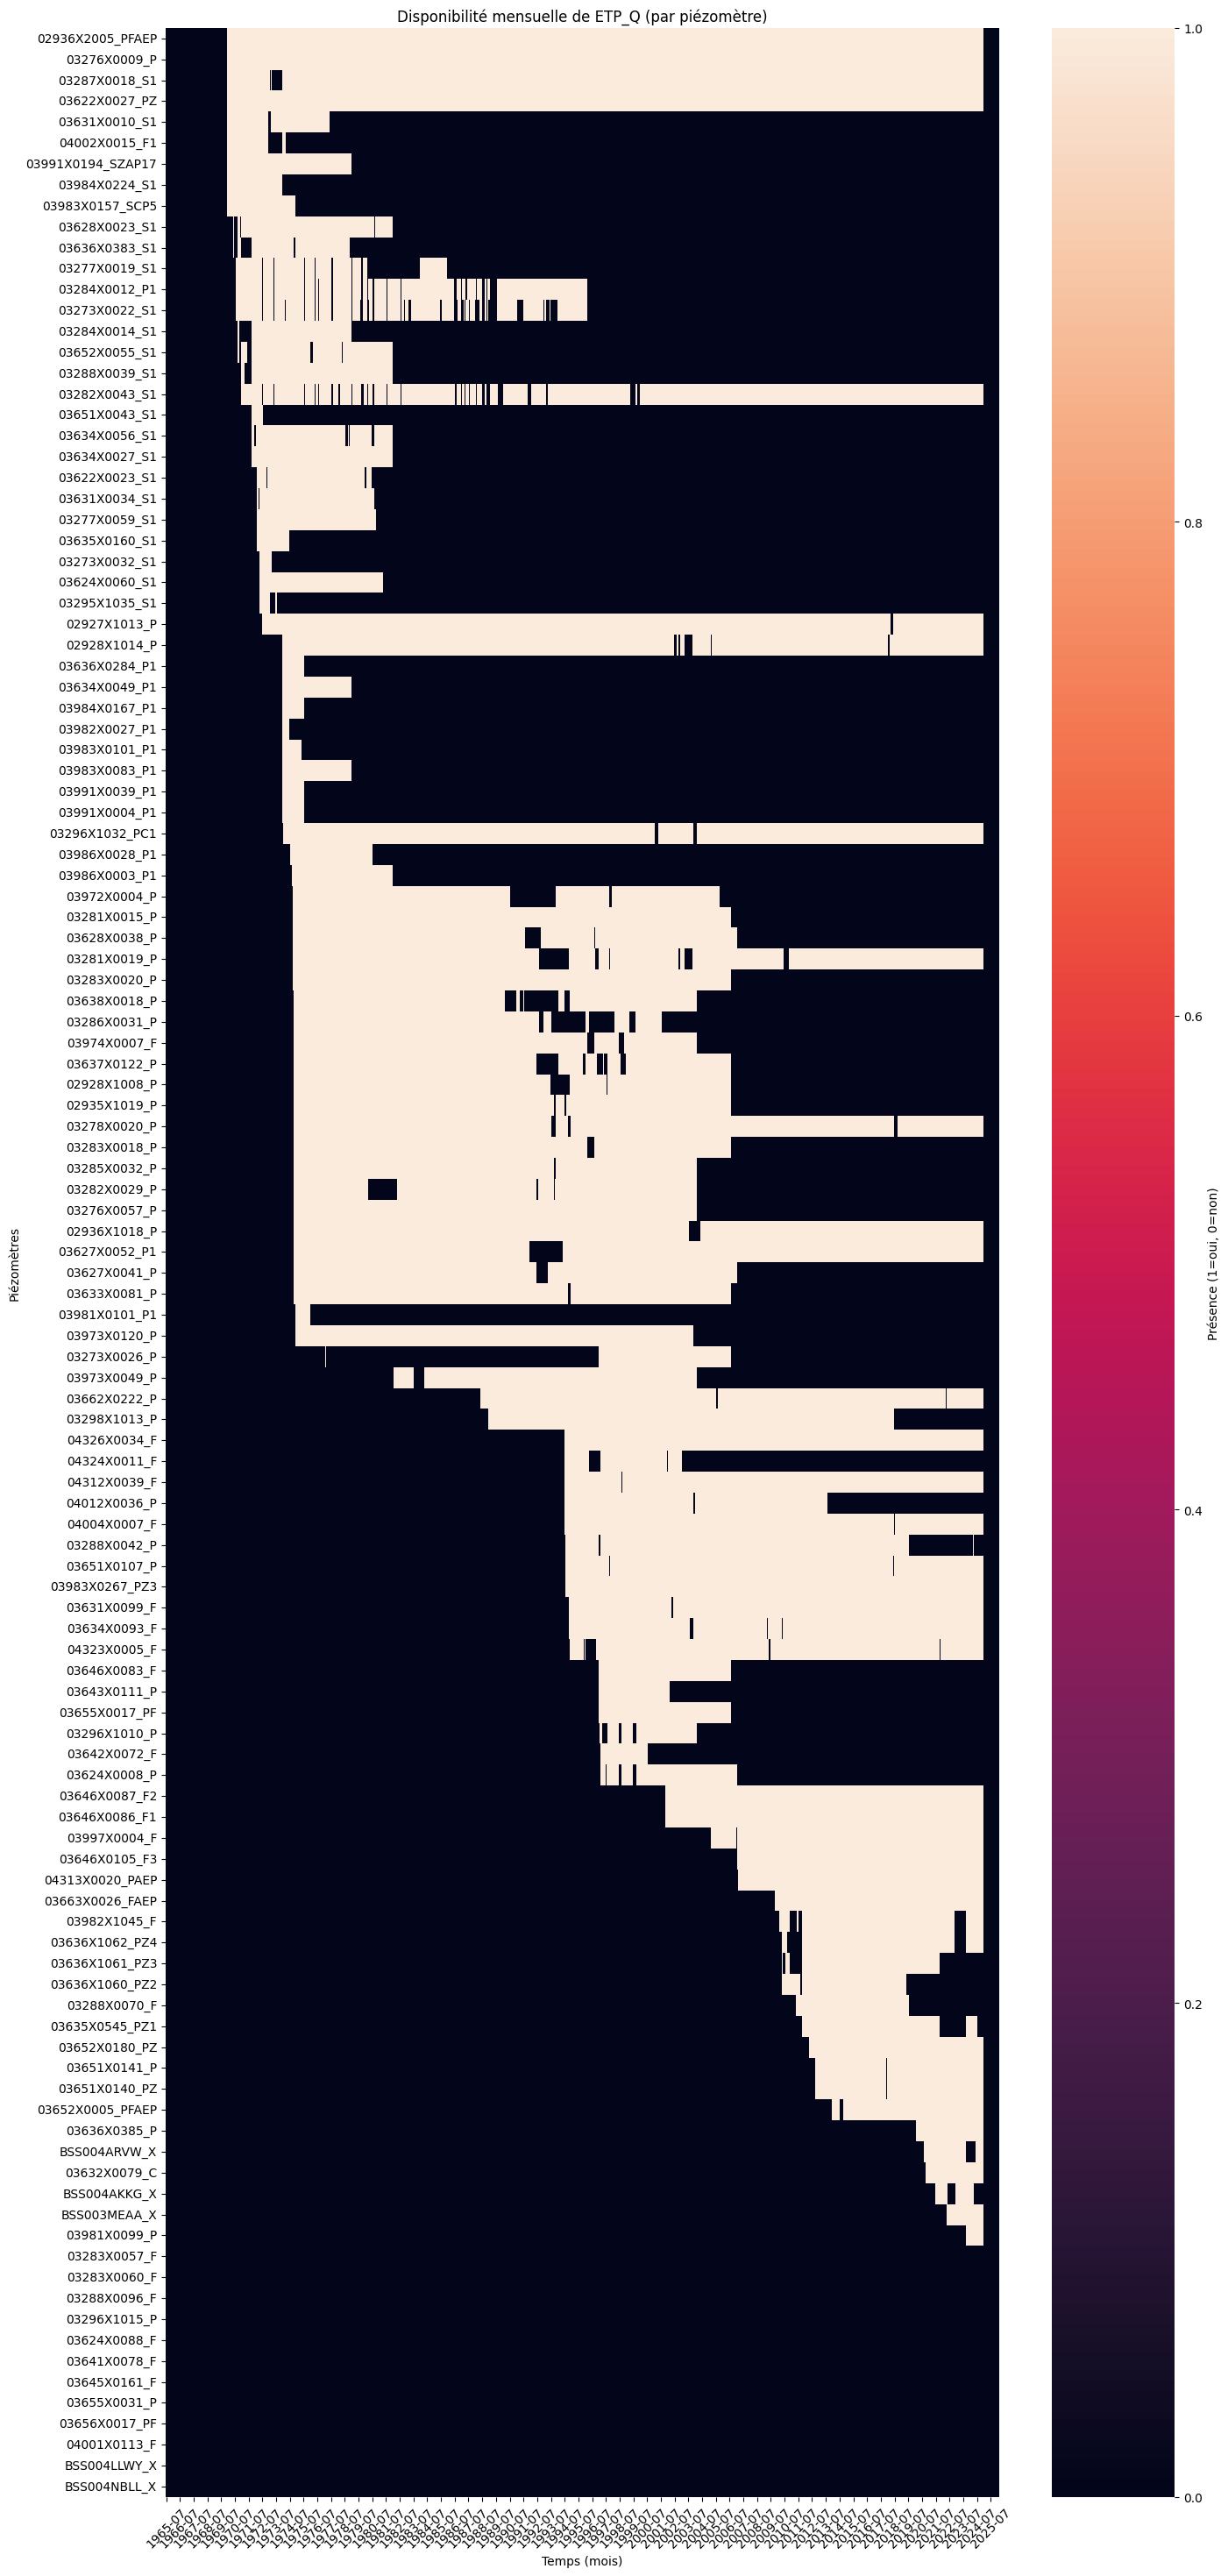

In [19]:
nom_variable = "ETP_Q"

def graph(nom_variable):
    all_series = []

    for file in os.listdir(output_folder):
        if not file.endswith(".csv"):
            continue
        
        path = os.path.join(output_folder, file)
        df = pd.read_csv(path, sep=";")
        
        if len(df) == 0 or "time" not in df.columns:
            continue
        
        if nom_variable not in df.columns:
            continue
        
        # Nom du piézomètre
        code = file.replace("data_", "").replace(".csv", "")
        
        # Date
        df["time"] = pd.to_datetime(df["time"])
        df["month"] = df["time"].dt.to_period("M")
        
        # Présence de données nappe (nom_variable)
        presence = (
            df.groupby("month")[nom_variable]
            .apply(lambda x: 1 if x.notna().any() else 0)
        )
        
        presence.name = code
        all_series.append(presence)

    if not all_series:
        return pd.DataFrame()

    activity_matrix = pd.concat(all_series, axis=1).T

    # Remplacer NaN par 0 (mois absents)
    activity_matrix = activity_matrix.fillna(0).astype(int)

    # Trier par première date active
    activity_matrix = activity_matrix.sort_index(axis=1)
    first_activity = activity_matrix.apply(
        lambda row: row[row == 1].index.min() if (row == 1).any() else None,
        axis=1
    )

    activity_matrix["first"] = first_activity
    activity_matrix = activity_matrix.sort_values("first")
    activity_matrix = activity_matrix.drop(columns="first")

    return activity_matrix

activity_matrix = graph(nom_variable)

print("Shape :", activity_matrix.shape)

plt.figure(figsize=(14, max(6, len(activity_matrix) * 0.25)))

sns.heatmap(
    activity_matrix,
    cbar_kws={"label": "Présence (1=oui, 0=non)"},
    vmin=0,
    vmax=1
)

plt.title(f"Disponibilité mensuelle de {nom_variable} (par piézomètre)")
plt.xlabel("Temps (mois)")
plt.ylabel("Piézomètres")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

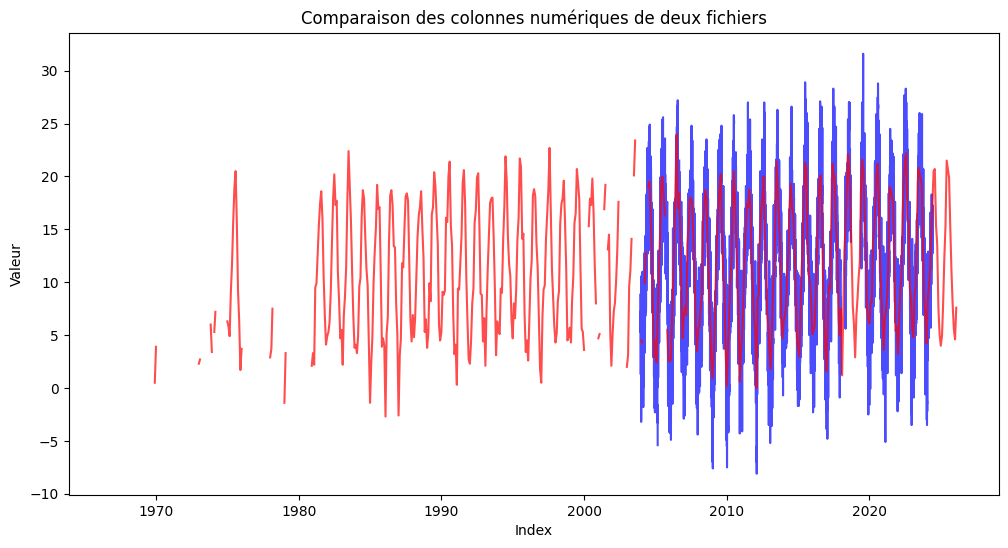

In [20]:
fichier1 = "../data/data_02923X0007_F.csv"

fichier2 = "../data/fusion/data_03276X0009_P.csv"
# fichier2 = "../data/fusion/data_03287X0018_S1.csv"

df1 = pd.read_csv(fichier1, sep=";")
df2 = pd.read_csv(fichier2, sep=";")


cols1 = df1[['time','niveau_nappe_eau','PRELIQ_Q','T_Q','ETP_Q','code_bss']][['time','T_Q']].select_dtypes(include='number').columns
# cols1 = df1[['time','niveau_nappe_eau']].select_dtypes(include='number').columns
cols2 = df2[['time','T_Q']].select_dtypes(include='number').columns

plt.figure(figsize=(12,6))

color1 = 'blue'
color2 = 'red'
df1['time'] = pd.to_datetime(df1['time'], errors='coerce')
df2['time'] = pd.to_datetime(df2['time'], errors='coerce')

# Trier par date (très important)
df1 = df1.sort_values('time')
df2 = df2.sort_values('time')
for col in cols1:
    plt.plot(df1['time'],df1[col], color=color1, alpha=0.7, label=f"Fichier1: {col}")

for col in cols2:
    plt.plot(df2['time'],df2[col], color=color2, alpha=0.7, label=f"Fichier2: {col}")

plt.xlabel("Index")
plt.ylabel("Valeur")
plt.title("Comparaison des colonnes numériques de deux fichiers")

plt.show()